In [1]:

import scanpy as sc
import os

file_id = "clean_testing_file_1.h5ad"
UPLOAD_DIR = "../../../persistent01"

file_path = os.path.join(UPLOAD_DIR, file_id)

adata = sc.read_h5ad(file_path)

adata


AnnData object with n_obs × n_vars = 177170 × 44643
    obs: 'run_id', 'sample', 'region', 'run_batch', 'time_to_surgery_old', 'sex_old', 't21_old', 'disease_old', 'donor', 'enrichment', 'tissue', 'scrublet_score', 'scrublet_leiden', 'cluster_scrublet_score', 'doublet_pval', 'doublet_bh_pval', 'batch', 'percent_mito', 'percent_ribo', 'n_counts', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'QC', 'droplet', 'S_score', 'G2M_score', 'phase', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'doublet_cls', 'localAnnotation', 'globalAnnotation', 'region_final', 'sex_final', 'time_to_surgery_final', 't21_final', 'localAnnotation_region_final', 'tissue_final', 'localAnnotation1', 'globalAnnotation1', 'batch_key', 'leiden_1_0_test_2105_1', 'leiden_0_5_test_2105_1', 'leiden_1_5_test_2105_1', 'leiden_3_0_test_2105_1', 'leiden_1_0_test_2505_1'
    var: 'gene_ids-0-0', 'n_cells-0-0', 'mt-

In [ ]:

adata.file.close()

In [2]:

uns_key = "leiden_0_5_test_2105_1"


In [3]:

top_genes = list(adata.var_names)

# top_genes = set()
# for group in adata.uns["rank_genes_groups"]["names"].dtype.names:
#   top_genes.update(adata.uns["rank_genes_groups"]["names"][group][:n_groups])  # top_n = 4

# top_genes


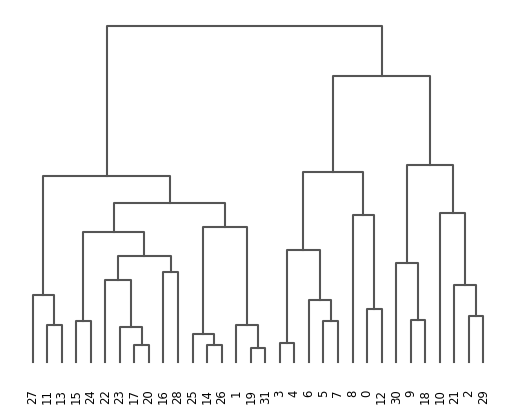

<Axes: >

In [4]:

sc.tl.dendrogram(adata, groupby=uns_key)
sc.pl.dendrogram(adata, groupby=uns_key)


In [ ]:

from scipy.cluster.hierarchy import linkage, to_tree
import json

def build_dendrogram_tree(linkage_matrix, labels: list[str]):
  
  tree, nodes = to_tree(linkage_matrix, rd=True)
  
  def add_node(node):
    if node.is_leaf():
      return {"name": node.id}
    else:
      return {
        "name": None,
        "children": [add_node(node.left), add_node(node.right)],
        "distance": node.dist  # Optional: include distance info
      }

  return add_node(tree)

dendrogram_data = adata.uns[f"dendrogram_{uns_key}"]
dendrogram_order = dendrogram_data["categories_ordered"]
  
dendrogram_tree = build_dendrogram_tree(dendrogram_data["linkage"], dendrogram_order)

dendrogram_tree

with open("d3_dendrogram_2705_3.json", "w") as f:
  json.dump(dendrogram_tree, f, indent=2)

In [ ]:

from scipy.cluster.hierarchy import to_tree, leaves_list

def build_dendrogram_tree(linkage_matrix, labels: list[str]):
    # Get the correct leaf order
    leaf_order = leaves_list(linkage_matrix)
    
    # Map from node id to label
    id_to_label = {i: labels[i] for i in range(len(labels))}
    
    # Build tree structure
    tree, _ = to_tree(linkage_matrix, rd=True)

    def serialize(node):
        if node.is_leaf():
            return {"name": id_to_label[node.id]}
        else:
            # Recursively serialize children
            children = [serialize(node.left), serialize(node.right)]
            
            # Optional: sort children based on the first leaf in the subtree to match leaf_order
            def first_leaf_id(subtree):
                if subtree["name"] is not None:
                    return leaf_order.tolist().index(labels.index(subtree["name"]))
                return min(first_leaf_id(c) for c in subtree["children"])
            
            children.sort(key=first_leaf_id)
            
            return {
                "name": None,
                "children": children,
                "distance": node.dist
            }

    return serialize(tree)


dendrogram_data = adata.uns[f"dendrogram_{uns_key}"]
dendrogram_order = dendrogram_data["categories_ordered"]
  
dendrogram_tree = build_dendrogram_tree(dendrogram_data["linkage"], dendrogram_order)

with open("d3_dendrogram_2705_2.json", "w") as f:
  json.dump(dendrogram_tree, f, indent=2)


In [ ]:

dp = sc.pl.DotPlot(adata, groupby=uns_key, var_names=sorted(top_genes))

dp.add_dendrogram().show()


In [ ]:

group_order = adata.uns[f"dendrogram_{uns_key}"]["categories_ordered"]

group_order


In [ ]:

mean_expr_df = dp.dot_color_df # mean expression
frac_expr_df = dp.dot_size_df # fraction expression

mean_expr_df = mean_expr_df.loc[group_order]
frac_expr_df = frac_expr_df.loc[group_order]

mean_expr_df


In [ ]:
combined_df = (
  mean_expr_df
  .stack()
  .to_frame("mean_expr")
  .join(frac_expr_df.stack().to_frame("frac_expr"))
  .reset_index()
  .rename(columns={"level_0": "group", "level_1": "gene"})
)

# print(mean_expr_df)
# print(frac_expr_df)

combined_df
# mean_expr_df

In [ ]:

combined_df.drop_duplicates("gene", keep="first")

genes = combined_df.drop_duplicates("gene", keep="first")["gene"].head(n_groups)
groups = combined_df.drop_duplicates("group", keep="first")["group"].head(n_groups)

print(genes)
print(groups)

# filtered_df = combined_df.drop_duplicates("gene", keep="first")
# # filtered_df = filtered_df.drop_duplicates("group", keep="first")

# filtered_df

In [ ]:

results_df = combined_df[combined_df["gene"].isin(genes) & combined_df["group"].isin(groups)]

results_df


In [ ]:

adata.uns_keys()

In [ ]:

rgg_vals = adata.uns["rank_genes_groups_leiden_0_5_test_2105_1"]

rgg_groups = rgg_vals["names"].dtype.names

rgg_groups

# rgg_vals.keys()
len(rgg_vals["logfoldchanges"][rgg_groups[5]])